# 02 — Modélisation pas à pas

Objectif : montrer, série par série puis modèle global, comment on passe des baselines à LightGBM,
avec les graphiques de diagnostic à chaque étape. C'est la version « pédagogique » et exécutable cellule
par cellule de ce que fait `src/demandforecast/pipeline.py` en une seule commande (`make pipeline`).

> **Ce que ce notebook n'est PAS** : le pipeline officiel fait un **backtest rolling-origin à 6 origines**
> sur **toutes** les séries (voir `pipeline.run_backtest`). Ici, pour que chaque étape reste lisible, on
> illustre sur **une seule série** et **un seul découpage train/test** (les 14 derniers jours). Les chiffres
> de ce notebook sont donc indicatifs, pas les chiffres à citer en entretien — ceux-là viennent de
> `reports/summary.md`, généré par `make pipeline`.

> Utilise Favorita si `data/raw/train.csv` existe, sinon des données synthétiques (mêmes réserves que dans `01_eda.ipynb` : les conclusions numériques ne valent alors que pour le test du notebook).

In [3]:
import sys
from pathlib import Path

# Robuste au dossier de lancement de Jupyter (racine du projet ou notebooks/)
for cand in [Path("../src"), Path("src"), Path.cwd().parent / "src"]:
    if (cand / "demandforecast").exists():
        sys.path.insert(0, str(cand.resolve()))
        break
else:
    raise FileNotFoundError("Dossier src/demandforecast introuvable : lancez Jupyter depuis la racine du projet ou depuis notebooks/.")

import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from demandforecast.data import load_favorita, make_synthetic, KEY
from demandforecast.features import build_features, make_maps, feature_columns
from demandforecast.models import seasonal_naive, moving_average, ets, sarima, prophet, STAT_MODELS, LGBMDirect
from demandforecast import metrics

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

RAW =Path("C:/Users/asus/Desktop/Demand forecasting project/data/raw")

ds = load_favorita(RAW) if (RAW / "train.csv").exists() else make_synthetic()
df, holidays = ds.df, ds.holidays
HORIZON = 14
print("Source :", ds.source, "| séries :", df.groupby(KEY).ngroups, "|", df.date.min().date(), "→", df.date.max().date())

Source : favorita | séries : 36 | 2015-01-01 → 2017-08-15


## 1. Le découpage train/test

Un seul point de coupure, à `HORIZON` jours de la fin de l'historique. **Jamais de split aléatoire** en série
temporelle : mélanger passé et futur fuit de l'information (un modèle « voit » des jours qu'il n'aurait pas
dans la vraie vie). Le pipeline officiel répète ce découpage 6 fois de suite (origines consécutives, non
chevauchées) pour une estimation plus stable ; ici on n'en garde qu'un pour la lisibilité.

In [4]:
last_date = df["date"].max()
cutoff = last_date - pd.Timedelta(days=HORIZON)
print(f"Entraînement : … → {cutoff.date()}  |  Test : {(cutoff + pd.Timedelta(days=1)).date()} → {last_date.date()} ({HORIZON} jours)")

# Série représentative pour illustrer les modèles "par série" : celle qui vend le plus (historique riche)
top_key = df.groupby(KEY)["sales"].sum().idxmax()
STORE, FAMILY = top_key
serie = df[(df["store_nbr"] == STORE) & (df["family"] == FAMILY)].sort_values("date")
hist = serie[serie["date"] <= cutoff]
test = serie[serie["date"] > cutoff]
print(f"Série illustrée : magasin {STORE} — {FAMILY}  ({len(hist)} jours d'historique, {len(test)} jours de test)")

Entraînement : … → 2017-08-01  |  Test : 2017-08-02 → 2017-08-15 (14 jours)
Série illustrée : magasin 45 — GROCERY I  (944 jours d'historique, 14 jours de test)


## 2. Baselines : le niveau à battre

`naïf saisonnier` répète la dernière semaine complète. `moyenne_mobile` prend la moyenne plate des 28
derniers jours. Un modèle plus complexe qui ne bat pas le naïf saisonnier n'a pas sa place en production :
il ajoute de la complexité sans gain.

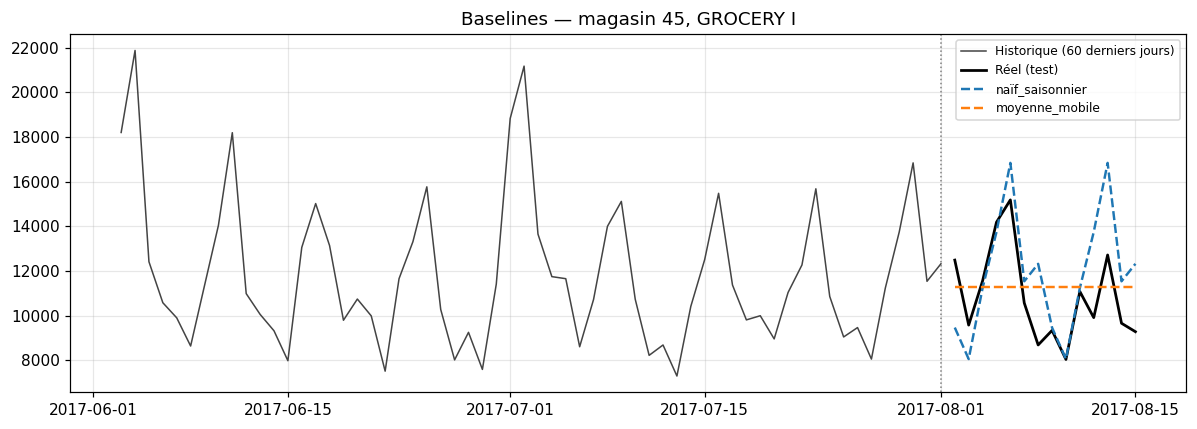

naïf_saisonnier    WAPE = 0.162  Biais = +0.093
moyenne_mobile     WAPE = 0.165  Biais = +0.037


In [5]:
baselines = {
    "naïf_saisonnier": seasonal_naive(hist["sales"].values, horizon=HORIZON),
    "moyenne_mobile": moving_average(hist["sales"].values, horizon=HORIZON),
}

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["date"].iloc[-60:], hist["sales"].iloc[-60:], color="#444", lw=1, label="Historique (60 derniers jours)")
ax.plot(test["date"], test["sales"].values, color="black", lw=1.8, label="Réel (test)")
for name, yhat in baselines.items():
    ax.plot(test["date"], yhat, lw=1.6, ls="--", label=name)
ax.axvline(cutoff, color="grey", ls=":", lw=1)
ax.set_title(f"Baselines — magasin {STORE}, {FAMILY}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for name, yhat in baselines.items():
    print(f"{name:18s} WAPE = {metrics.wape(test['sales'], yhat):.3f}  Biais = {metrics.bias(test['sales'], yhat):+.3f}")

## 3. ETS (lissage exponentiel de Holt-Winters)

Tendance amortie + saisonnalité hebdomadaire additive. Capture une dynamique plus fine que les baselines
mais reste un modèle par série (un ETS différent est ajusté pour chaque couple magasin × famille).

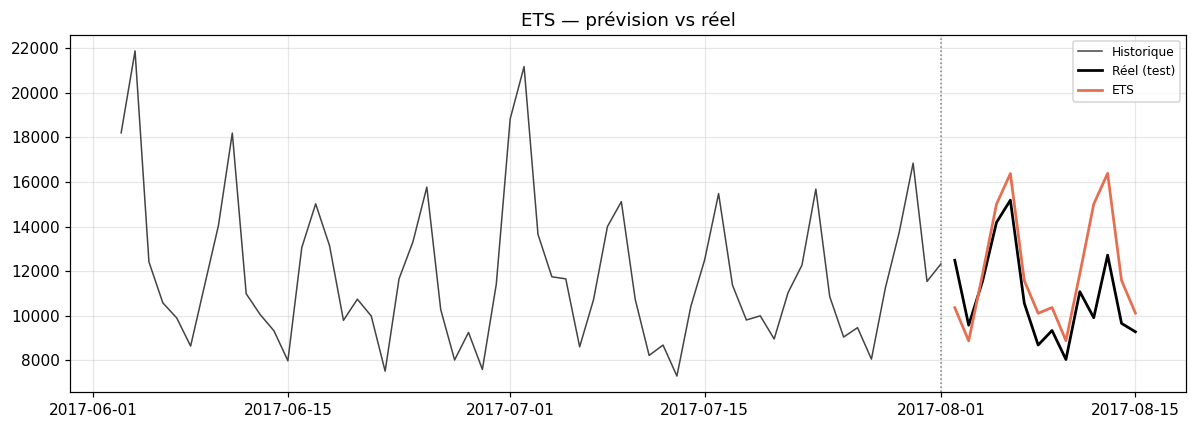

WAPE = 0.143  Biais = +0.106


In [7]:
yhat_ets = ets(hist["sales"].values, horizon=HORIZON)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["date"].iloc[-60:], hist["sales"].iloc[-60:], color="#444", lw=1, label="Historique")
ax.plot(test["date"], test["sales"].values, color="black", lw=1.8, label="Réel (test)")
ax.plot(test["date"], yhat_ets, color="#e76f51", lw=1.8, label="ETS")
ax.axvline(cutoff, color="grey", ls=":", lw=1)
ax.set_title("ETS — prévision vs réel"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"WAPE = {metrics.wape(test['sales'], yhat_ets):.3f}  Biais = {metrics.bias(test['sales'], yhat_ets):+.3f}")

## 4. SARIMA(1,0,1)(1,1,1)₇

Différenciation saisonnière d'ordre 7 : on modélise directement la variation semaine sur semaine. Plus lent à
ajuster qu'ETS, potentiellement plus précis si l'autocorrélation résiduelle est bien capturée — à vérifier sur
les résidus, pas seulement sur le WAPE.

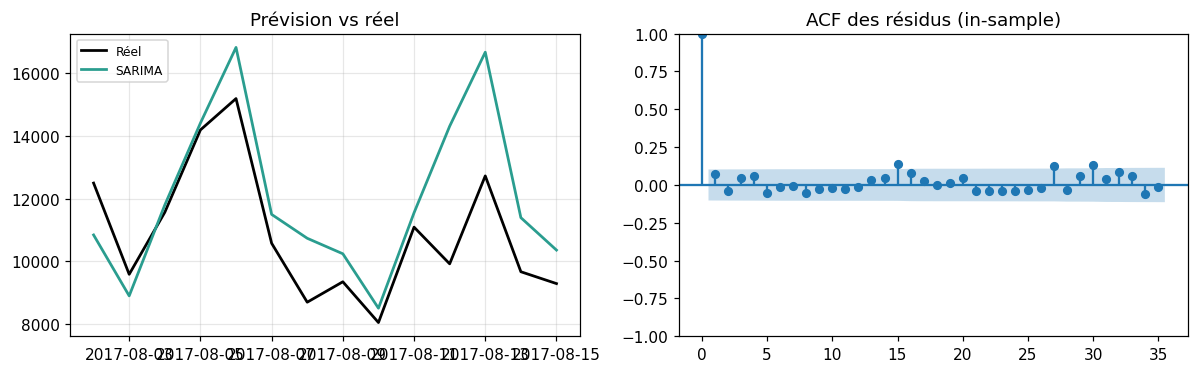

WAPE = 0.133  Biais = +0.103
Résidus : si des pics dépassent la bande grisée à des décalages 7/14/21, la saisonnalité n'est pas complètement capturée.


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

y_train = hist["sales"].values[-365:]
fit = SARIMAX(y_train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=60)
yhat_sarima = np.clip(fit.forecast(HORIZON), 0, None)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(test["date"], test["sales"].values, color="black", lw=1.8, label="Réel")
axes[0].plot(test["date"], yhat_sarima, color="#2a9d8f", lw=1.8, label="SARIMA")
axes[0].legend(fontsize=8); axes[0].set_title("Prévision vs réel"); axes[0].grid(alpha=0.3)
plot_acf(fit.resid, lags=35, ax=axes[1]); axes[1].set_title("ACF des résidus (in-sample)")
plt.tight_layout(); plt.show()
print(f"WAPE = {metrics.wape(test['sales'], yhat_sarima):.3f}  Biais = {metrics.bias(test['sales'], yhat_sarima):+.3f}")
print("Résidus : si des pics dépassent la bande grisée à des décalages 7/14/21, la saisonnalité n'est pas complètement capturée.")

## 5. Prophet (saisonnalités + jours fériés)

Optionnel (dépendance lourde) : si le paquet `prophet` n'est pas installé ou que l'ajustement échoue,
`models.prophet` retombe automatiquement sur le naïf saisonnier — comportement voulu en production
(mieux vaut une prévision médiocre qu'un pipeline qui plante).

17:28:34 - cmdstanpy - INFO - Chain [1] start processing
17:28:35 - cmdstanpy - INFO - Chain [1] done processing


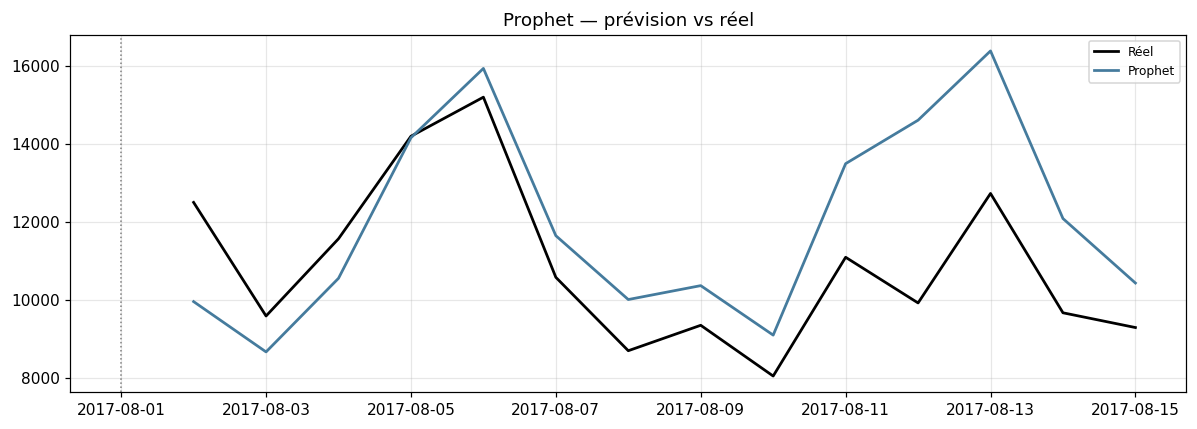

WAPE = 0.157  Biais = +0.098


In [11]:
try:
    yhat_prophet = prophet(hist["sales"].values, horizon=HORIZON, dates=pd.DatetimeIndex(hist["date"]), holidays=holidays)
    ok = True
except Exception as e:
    print("Prophet indisponible :", e)
    yhat_prophet, ok = seasonal_naive(hist["sales"].values, horizon=HORIZON), False

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test["date"], test["sales"].values, color="black", lw=1.8, label="Réel")
ax.plot(test["date"], yhat_prophet, color="#457b9d", lw=1.8, label="Prophet" if ok else "Prophet (repli naïf)")
ax.axvline(cutoff, color="grey", ls=":", lw=1)
ax.legend(fontsize=8); ax.set_title("Prophet — prévision vs réel"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"WAPE = {metrics.wape(test['sales'], yhat_prophet):.3f}  Biais = {metrics.bias(test['sales'], yhat_prophet):+.3f}")

## 6. LightGBM direct (modèle global)

Change de nature : un seul modèle pour **toutes** les séries à la fois (partage l'information entre magasins
et familles), stratégie **directe** (un jeu de variables prévoit les `HORIZON` jours d'un coup, aucun décalage
< `HORIZON` n'est utilisé — voir `features.build_features`, testé contre les fuites dans `tests/test_features.py`).
Deux régressions quantiles (5 %/95 %) donnent un intervalle de prévision en plus du point.

In [12]:
store_map, family_map = make_maps(df)
feats = build_features(df, HORIZON, holidays, store_map, family_map)

train_f = feats[feats["date"] <= cutoff]
test_f = feats[(feats["date"] > cutoff) & (feats["date"] <= last_date)]

model = LGBMDirect(HORIZON).fit(train_f)
pred = model.predict(test_f)
print(f"{len(feature_columns(HORIZON))} variables | {len(train_f):,} lignes d'entraînement (après retrait des NaN de décalage)")

21 variables | 33,984 lignes d'entraînement (après retrait des NaN de décalage)


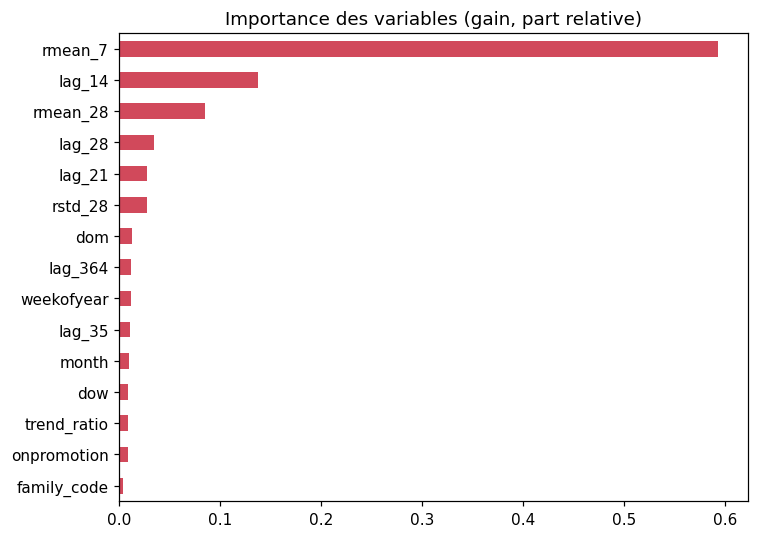

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
imp = model.importance()
(imp / imp.sum()).tail(15).plot.barh(ax=ax, color="#d1495b")
ax.set_title("Importance des variables (gain, part relative)")
plt.tight_layout(); plt.show()

### Prévision sur la série illustrée, avec intervalle

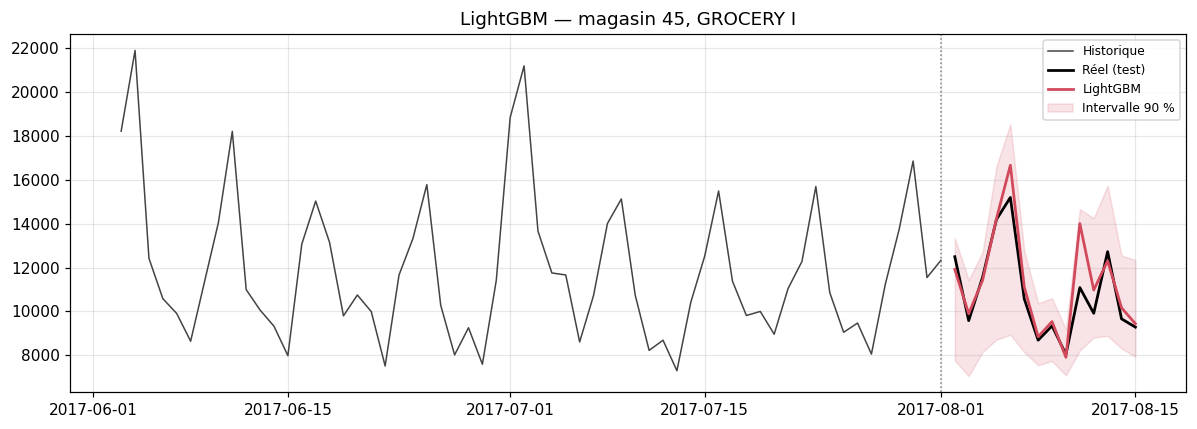

WAPE = 0.056  Biais = +0.040
Couverture intervalle 90 % : 100% (cible : 90 %)


In [14]:
mask = (test_f["store_nbr"] == STORE) & (test_f["family"] == FAMILY)
p = pred[mask].assign(date=test_f.loc[mask, "date"].values).sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["date"].iloc[-60:], hist["sales"].iloc[-60:], color="#444", lw=1, label="Historique")
ax.plot(test["date"], test["sales"].values, color="black", lw=1.8, label="Réel (test)")
ax.plot(p["date"], p["yhat"], color="#d1495b", lw=1.8, label="LightGBM")
ax.fill_between(p["date"], p["yhat_lo"], p["yhat_hi"], color="#d1495b", alpha=0.15, label="Intervalle 90 %")
ax.axvline(cutoff, color="grey", ls=":", lw=1)
ax.legend(fontsize=8); ax.set_title(f"LightGBM — magasin {STORE}, {FAMILY}"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

y_serie = test_f.loc[mask, "sales"].values
print(f"WAPE = {metrics.wape(y_serie, p['yhat']):.3f}  Biais = {metrics.bias(y_serie, p['yhat']):+.3f}")
print(f"Couverture intervalle 90 % : {metrics.coverage(y_serie, p['yhat_lo'], p['yhat_hi']):.0%} (cible : 90 %)")

### Diagnostic des résidus (toutes séries, sur ce découpage)

Un biais qui dérive selon le jour de l'horizon indique que le modèle se dégrade en prévisant plus loin — à
surveiller si l'horizon business dépasse 14 jours.

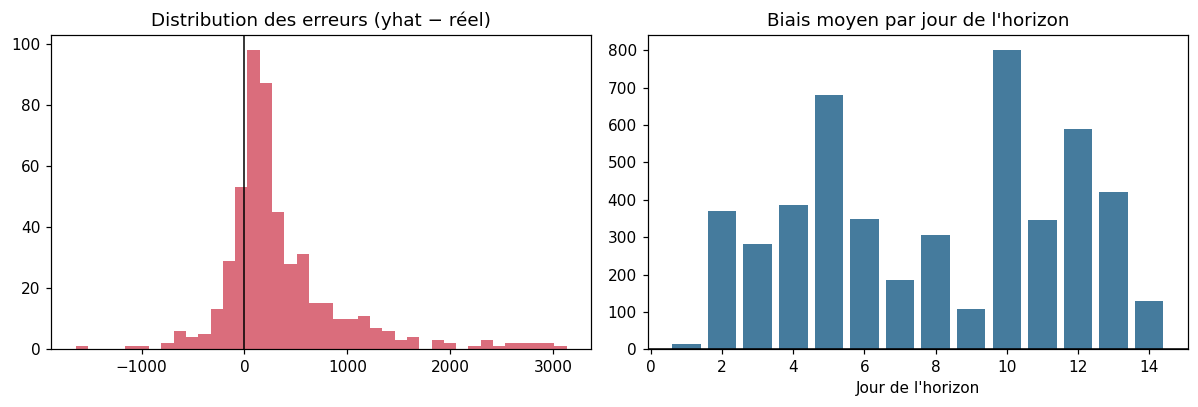

In [15]:
res = pred.assign(y=test_f["sales"].values, date=test_f["date"].values, horizon_day=(test_f["date"] - cutoff).dt.days.values)
res["error"] = res["yhat"] - res["y"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(res["error"], bins=40, color="#d1495b", alpha=0.8)
axes[0].axvline(0, color="black", lw=1); axes[0].set_title("Distribution des erreurs (yhat − réel)")
by_h = res.groupby("horizon_day")["error"].mean()
axes[1].bar(by_h.index, by_h.values, color="#457b9d")
axes[1].axhline(0, color="black", lw=1); axes[1].set_title("Biais moyen par jour de l'horizon"); axes[1].set_xlabel("Jour de l'horizon")
plt.tight_layout(); plt.show()

## 7. Comparaison sur cette série et ce découpage

⚠️ Un seul fold, une seule série : ordre indicatif seulement. La comparaison qui compte (6 origines, toutes
séries, MASE inclus) est dans `reports/summary.md` après `make pipeline`.

In [16]:
rows = []
for name, yhat in {**baselines, "ets": yhat_ets, "sarima": yhat_sarima, "prophet": yhat_prophet}.items():
    rows.append({"modèle": name, "WAPE": metrics.wape(test["sales"], yhat), "Biais": metrics.bias(test["sales"], yhat)})
rows.append({"modèle": "lightgbm", "WAPE": metrics.wape(y_serie, p["yhat"]), "Biais": metrics.bias(y_serie, p["yhat"])})
comparaison = pd.DataFrame(rows).sort_values("WAPE").reset_index(drop=True)
comparaison

,modèle,WAPE,Biais
0,lightgbm,0.056444,0.039787
1,sarima,0.133417,0.102666
2,ets,0.143073,0.105929
3,prophet,0.157425,0.098159
4,naïf_saisonnier,0.162372,0.092745
5,moyenne_mobile,0.164627,0.036523


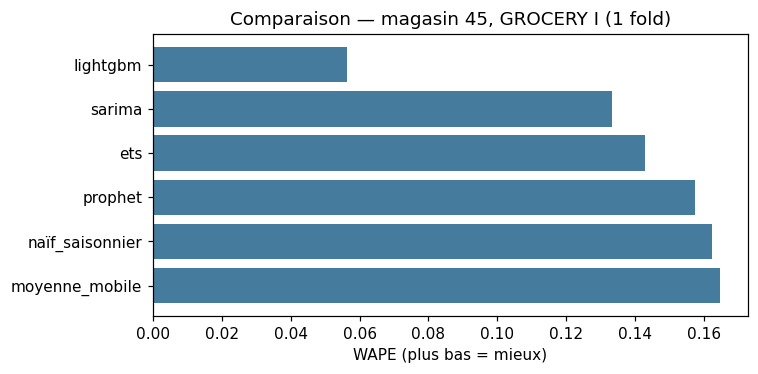

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(comparaison["modèle"], comparaison["WAPE"], color="#457b9d")
ax.invert_yaxis(); ax.set_xlabel("WAPE (plus bas = mieux)"); ax.set_title(f"Comparaison — magasin {STORE}, {FAMILY} (1 fold)")
plt.tight_layout(); plt.show()

## 8. Et maintenant ?

Ce notebook illustre le raisonnement modèle par modèle. Pour les chiffres à présenter (backtest 6 origines,
toutes séries, intervalles calibrés, simulation de stock) :

```bash
make pipeline          # ou : python -m demandforecast.pipeline --data-dir data/raw --horizon 14 --n-folds 6
```

qui écrit `reports/summary.md`, `reports/figures/*.png` et le modèle final dans `models/artifacts.joblib`.